In [ ]:
#Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
## Loading Data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Target"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDescriptive Statistics:")
display(df.describe())

Dataset Shape: (150, 5)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Target                 int64
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
df["Species"] = df["Target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target,Species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


Number of samples for each species:
Species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


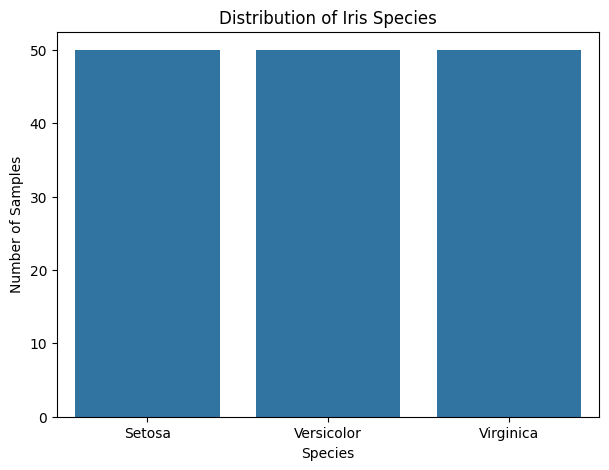

In [ ]:
## Model Training
print("Number of samples for each species:")
print(df["Species"].value_counts())
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Species")
plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.show()

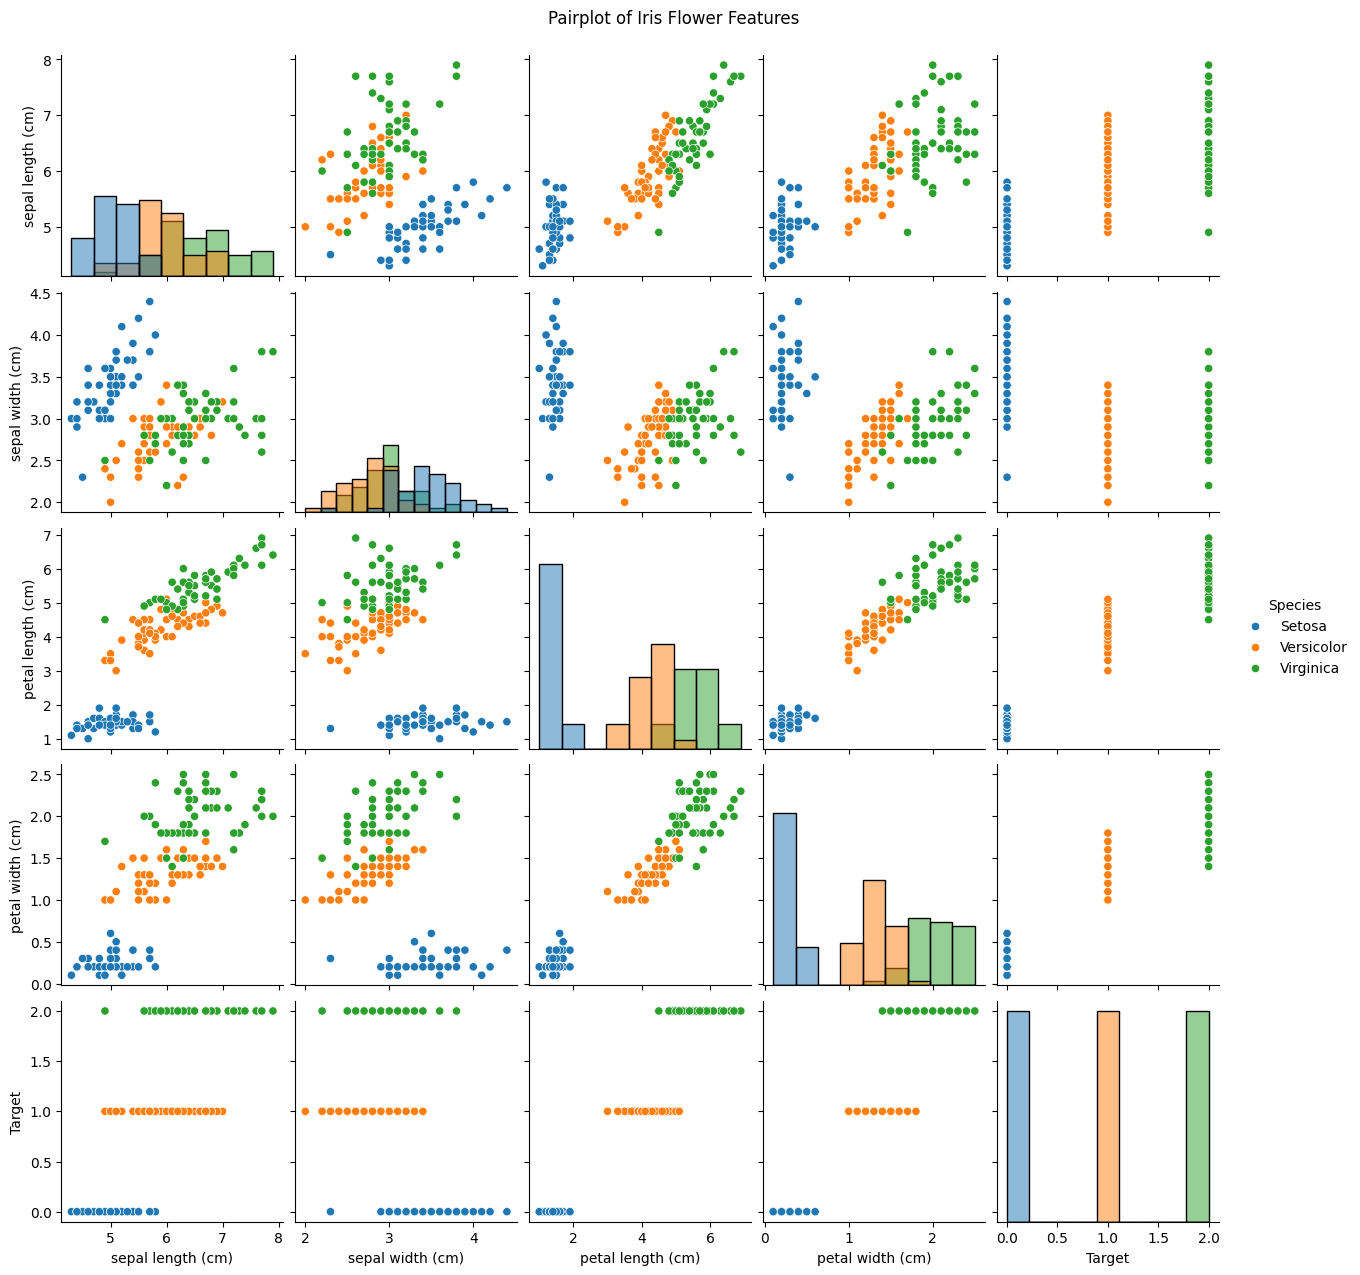

In [ ]:
## Model Evaluation
sns.pairplot(
    df,
    hue="Species",
    diag_kind="hist"
)
plt.suptitle("Pairplot of Iris Flower Features", y=1.02)
plt.show()

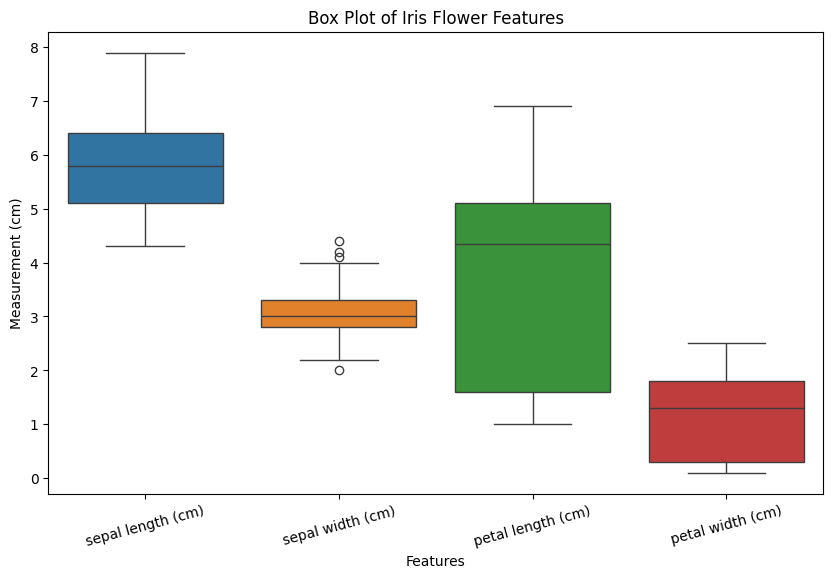

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df[iris.feature_names]
)
plt.title("Box Plot of Iris Flower Features")
plt.xlabel("Features")
plt.ylabel("Measurement (cm)")
plt.xticks(rotation=15)
plt.show()

In [ ]:
X = df[iris.feature_names]
y = df["Target"]
print("Selected Features:")
print(X.columns.tolist())
print("\nTarget:")
print("Iris Species")

Selected Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target:
Iris Species


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [ ]:
model_lr = LogisticRegression(max_iter=200)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print("Logistic Regression model trained successfully!")
print("Predictions:", y_pred_lr)

Logistic Regression model trained successfully!
Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
print("KNN model trained successfully!")
print("Predictions:", y_pred_knn)

KNN model trained successfully!
Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
for name, y_pred in [("Logistic Regression", y_pred_lr), ("KNN", y_pred_knn)]:
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


===== Logistic Regression =====
Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


===== KNN =====
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1

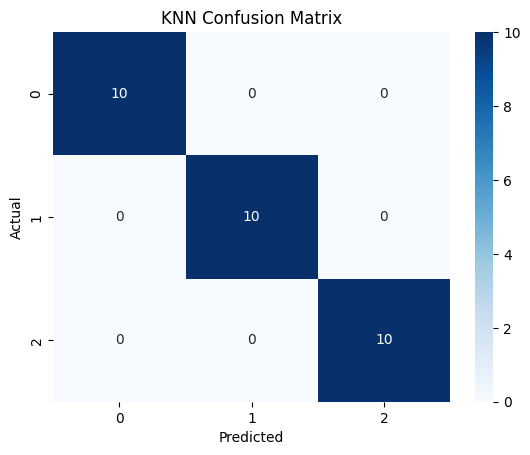

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model Comparison:
Logistic Regression Accuracy: 0.XX
KNN Accuracy: 0.XX
Conclusion: [Best model name] performed better, so we select it as the final model.